In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np
import shap

In [3]:
all_tornados = pd.read_csv('data/1950-2021_actual_tornadoes.csv')

In [4]:
all_tornados

,om,yr,mo,dy,date,time,tz,st,stf,stn,...,len,wid,ns,sn,sg,f1,f2,f3,f4,fc
0,192,1950,10,1,1950-10-01,21:00:00,3,OK,40,23,...,15.80,10,1,1,1,25,0,0,0,0
1,193,1950,10,9,1950-10-09,02:15:00,3,NC,37,9,...,2.00,880,1,1,1,47,0,0,0,0
2,195,1950,11,20,1950-11-20,02:20:00,3,KY,21,1,...,0.10,10,1,1,1,177,0,0,0,0
3,196,1950,11,20,1950-11-20,04:00:00,3,KY,21,2,...,0.10,10,1,1,1,209,0,0,0,0
4,197,1950,11,20,1950-11-20,07:30:00,3,MS,28,14,...,2.00,37,1,1,1,101,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67553,620523,2021,9,8,2021-09-08,15:32:00,3,PA,42,0,...,0.73,30,1,1,1,109,0,0,0,0
67554,620524,2021,9,8,2021-09-08,15:35:00,3,PA,42,0,...,1.45,30,1,1,1,109,0,0,0,0
67555,620525,2021,9,8,2021-09-08,19:08:00,3,FL,12,0,...,1.45,50,1,1,1,129,0,0,0,0
67556,620526,2021,9,9,2021-09-09,02:10:00,3,CT,9,0,...,0.75,75,1,1,1,13,0,0,0,0


In [5]:
sel_states = ['IL', 'IN', 'IA', 'MI', 'MO']
Midwest_Tornadoes = all_tornados[all_tornados['st'].isin(sel_states)]
Midwest_Tornadoes.set_index(pd.to_datetime(Midwest_Tornadoes['date']), inplace = True)
Midwest_tor_count = Midwest_Tornadoes.resample('MS').size()


In [6]:
EPNA_data = pd.read_csv('data/EPNA_1951_2025')
EPNA_data.rename(columns = {'Date': 'date'}, inplace = True)
EPNA_data['date'] = pd.to_datetime(EPNA_data['date'])
EPNA_data.set_index('date', inplace = True)

Mw_Tor_Tele = pd.merge(left = Midwest_tor_count.rename('monthly_count'), right = EPNA_data, on = 'date', how = 'inner')

In [7]:
Mw_Tor_Tele

,monthly_count,ENSO,PDO,NAO,AO
date,,,,,
1951-01-01,0,1.5,-1.19,0.08,-0.085
1951-02-01,0,0.9,-1.52,0.70,-0.400
1951-03-01,1,-0.1,-1.72,-1.02,-1.934
1951-04-01,0,-0.3,-1.35,-0.22,-0.776
1951-05-01,2,-0.7,-1.29,-0.59,-0.863
...,...,...,...,...,...
2021-08-01,36,0.6,-0.95,-0.28,-0.209
2021-09-01,1,0.8,-1.96,-0.21,-0.252
2021-10-01,33,0.7,-3.13,-2.29,-0.146


In [8]:
# Checking for missing values

Mw_Tor_Tele.isna().sum()

monthly_count    0
ENSO             0
PDO              0
NAO              0
AO               0
dtype: int64

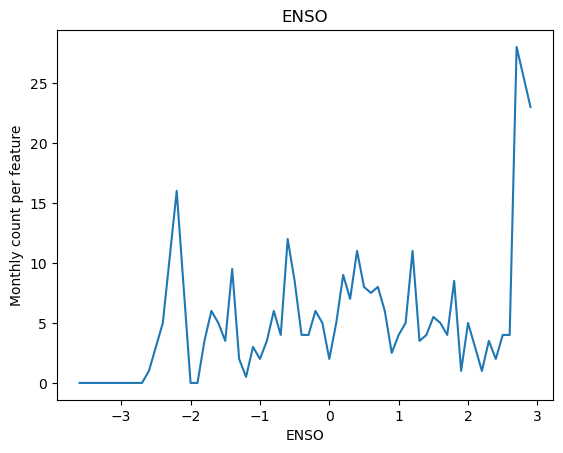

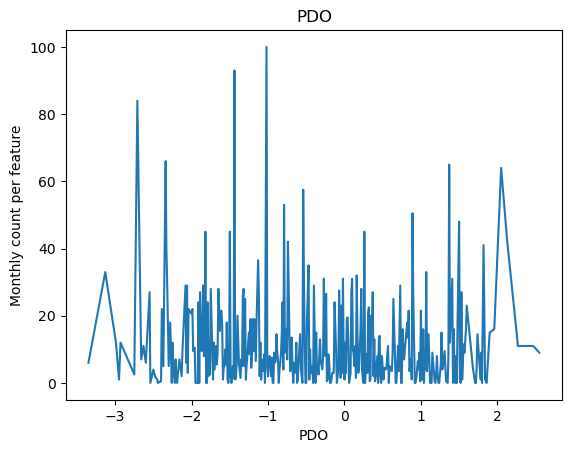

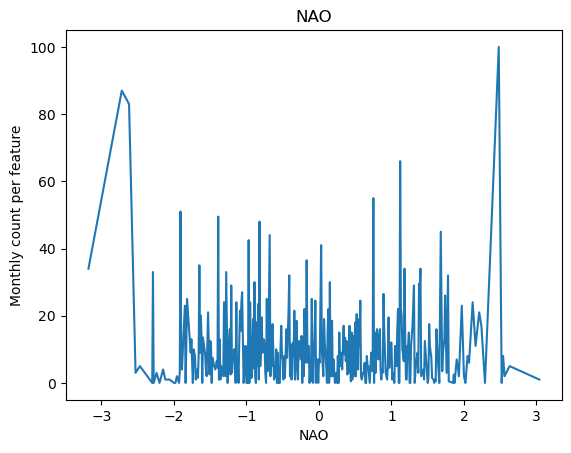

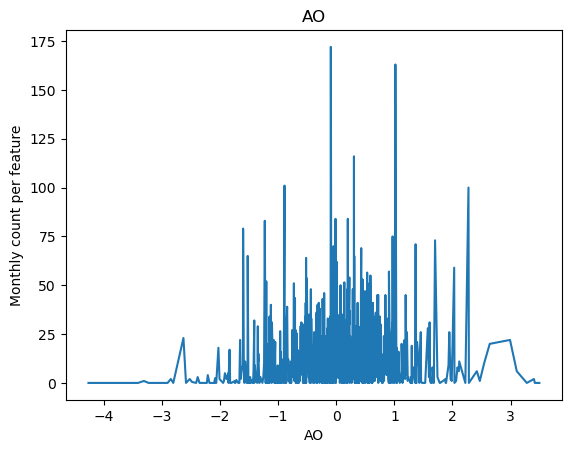

In [9]:
# taking a look at the distribution of counts for each feature

training_features = ['ENSO', 'PDO', 'NAO', 'AO']

for feature in training_features:
    Mw_Tor_Tele.groupby(feature)['monthly_count'].median().plot()
    plt.ylabel('Monthly count per feature')
    plt.title(feature)
    plt.show()

In [10]:
# splitting the data into target features and training features.

Y = Mw_Tor_Tele['monthly_count']
X = Mw_Tor_Tele.drop(['monthly_count'], axis = 1)

In [ ]:
# conducted a cv grid search to find the optimal settings.
# it ended up performing worse than the default settings.

param_grid = {
 "max_depth": [10, 25, 50, 100],
 "learning_rate": [0.01, 0.1, 0.5, 0.7],
 "min_samples_leaf": [1,2,3,4,5],
 "n_estimators": [25, 50, 100, 200, 400]}

grid = GridSearchCV(GradientBoostingRegressor(), param_grid=param_grid, cv = 7)



In [ ]:
grid.fit(X,Y)

In [ ]:
grid.best_params_

{'learning_rate': 0.01,
 'max_depth': 100,
 'min_samples_leaf': 5,
 'n_estimators': 25}

In [ ]:
grid.cv_results_

In [11]:
# Splitting the data into training sets and test sets

Y = Mw_Tor_Tele['monthly_count']
X = Mw_Tor_Tele.drop('monthly_count', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25 )

In [13]:
# Training a Gradient Boosting Regressor with parameters 
# determined by a CV grid search.

gbr_model_opt = GradientBoostingRegressor(learning_rate = 0.1,
                                      max_depth = 100,
                                      min_samples_leaf = 5,
                                      n_estimators = 25)

gbr_model_opt.fit(X_train, y_train)
gbr_predicted_opt = gbr_model_opt.predict(X_test)

# Computing model performance scores
gbr_opt_R2 = r2_score(y_test, gbr_predicted_opt)
gbr_opt_rmse = root_mean_squared_error(y_test, gbr_predicted_opt)

print("R2 Score the Gradient Boosting Regression is ", gbr_opt_R2)
print("RMSE Score the Gradient Boosting Regression is ", gbr_opt_rmse)

# Computing a cross val to affirm the above results
opt_cross_scores = cross_val_score(gbr_model_opt, X, Y, cv = 7, scoring = 'r2')

print('\n')
print("Using a 7-fold cross-validation we see R2 scores of:")
print(opt_cross_scores)

print('With a mean score of:')
print(opt_cross_scores.mean())




R2 Score the Gradient Boosting Regression is  -0.1266264154581942
RMSE Score the Gradient Boosting Regression is  18.081869192701422


Using a 7-fold cross-validation we see R2 scores of:
[-1.31662946 -0.66360455 -0.10501861 -0.18827341 -0.06253655 -0.1372389
 -0.32734213]
With a mean score of:
-0.4000919439907888


Text(22, 90, 'Correlation Coefficient 0.096')

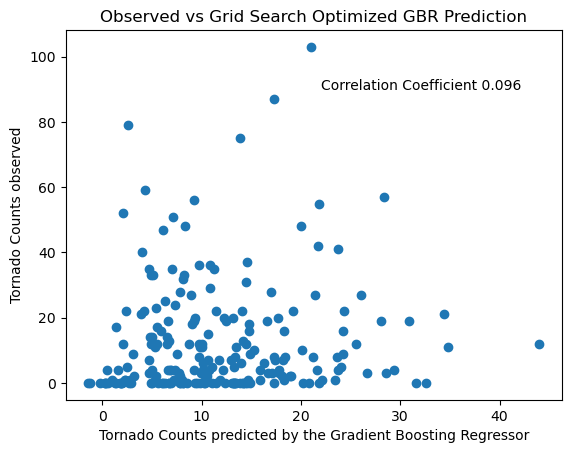

In [14]:
coco = pearsonr(gbr_predicted_opt, y_test)
plt.scatter(gbr_predicted_opt, y_test)
plt.title('Observed vs Grid Search Optimized GBR Prediction')
plt.xlabel('Tornado Counts predicted by the Gradient Boosting Regressor')
plt.ylabel('Tornado Counts observed')

plt.text(x = 22, y = 90, s = "Correlation Coefficient " + str(np.round(coco.statistic, 3)))

In [15]:
# Training a Gradient Boosting Regressor with default
# values.

gbr_model = GradientBoostingRegressor()
gbr_model.fit(X_train, y_train)
gbr_model.score(X_test, y_test)

gbr_model.fit(X_train, y_train)
gbr_predicted = gbr_model.predict(X_test)

# Computing model performance scores
gbr_R2 = r2_score(y_test, gbr_predicted)
gbr_rmse = root_mean_squared_error(y_test, gbr_predicted)

print("R2 Score the Gradient Boosting Regression is ", gbr_R2)
print("RMSE Score the Gradient Boosting Regression is ", gbr_rmse)

# Computing a cross val to affirm the above results
cross_scores = cross_val_score(gbr_model, X, Y, cv = 7, scoring = 'r2')

print('\n')
print("Using a 7-fold cross-validation we see R2 scores of:")
print(cross_scores)
print('With a mean score of:')
print(cross_scores.mean())

R2 Score the Gradient Boosting Regression is  -0.12371879311951517
RMSE Score the Gradient Boosting Regression is  18.058521074926382


Using a 7-fold cross-validation we see R2 scores of:
[-0.96084355 -0.21901083 -0.17954317 -0.28863155  0.09704166 -0.12036944
 -0.24209435]
With a mean score of:
-0.27335017576045245


Text(45, 90, 'Correlation Coefficient 0.445')

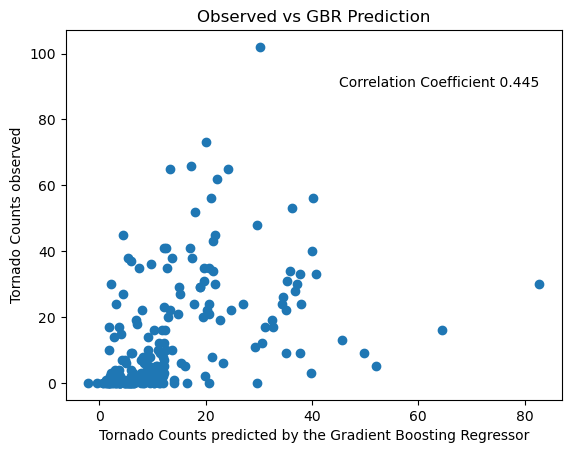

In [80]:
coco = pearsonr(gbr_predicted, y_test)

plt.scatter(gbr_predicted, y_test)
plt.title('Observed vs GBR Prediction')
plt.xlabel('Tornado Counts predicted by the Gradient Boosting Regressor')
plt.ylabel('Tornado Counts observed')

plt.text(x = 45, y = 90, s = "Correlation Coefficient " + str(np.round(coco.statistic, 3)))

In [16]:
vec = CountVectorizer()

months = vec.fit_transform(Mw_Tor_Tele.index.month_name())
months = pd.DataFrame(months.toarray(), columns=vec.get_feature_names_out())
months.set_index(Mw_Tor_Tele.index, inplace = True)
Mw_Tor_Tele = pd.concat([Mw_Tor_Tele, months], axis = 1)

In [17]:
Y = Mw_Tor_Tele['monthly_count']
X = Mw_Tor_Tele.drop('monthly_count', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25 )

In [18]:
# Training a Gradient Boosting Regressor with One-Hot encoding
# in the dataset.

gbr_model_OH = GradientBoostingRegressor()
gbr_model_OH.fit(X_train, y_train)
gbr_model_OH.score(X_test, y_test)

gbr_model_OH.fit(X_train, y_train)
gbr_predicted_OH = gbr_model_OH.predict(X_test)

# Computing model performance scores
gbr_R2 = r2_score(y_test, gbr_predicted_OH)
gbr_rmse = root_mean_squared_error(y_test, gbr_predicted_OH)

print("R2 Score for the Gradient Boosting Regression with One Hot encoding of the months is ", gbr_R2)
print("RMSE Score forthe Gradient Boosting Regression with One Hot encoding of the months is ", gbr_rmse)

# Computing a cross val to affirm the above results
cross_scores = cross_val_score(gbr_model_OH, X, Y, cv = 7, scoring = 'r2')

print('\n')
print("Using a 7-fold cross-validation we see R2 scores of:")
print(cross_scores)
print('With a mean score of:')
print(cross_scores.mean())

R2 Score for the Gradient Boosting Regression with One Hot encoding of the months is  0.11783195846013184
RMSE Score forthe Gradient Boosting Regression with One Hot encoding of the months is  15.739998983871008


Using a 7-fold cross-validation we see R2 scores of:
[-1.12929671 -0.10491431  0.33862454  0.21970521  0.33738674  0.14278879
  0.04328908]
With a mean score of:
-0.021773809075491472


Text(50, 90, 'Correlation Coefficient 0.467')

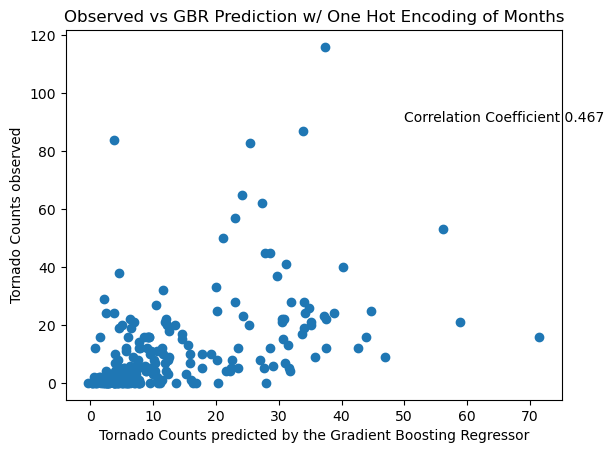

In [19]:
coco = pearsonr(gbr_predicted_OH, y_test)
plt.scatter(gbr_predicted_OH, y_test)
plt.title('Observed vs GBR Prediction w/ One Hot Encoding of Months')
plt.xlabel('Tornado Counts predicted by the Gradient Boosting Regressor')
plt.ylabel('Tornado Counts observed')
plt.text(x = 50, y = 90, s = "Correlation Coefficient " + str(np.round(coco.statistic, 3)))

In [20]:
feature_names = gbr_model_OH.feature_names_in_

mdi_importances = pd.Series(
    gbr_model_OH.feature_importances_, index=feature_names
).sort_values(ascending=True)

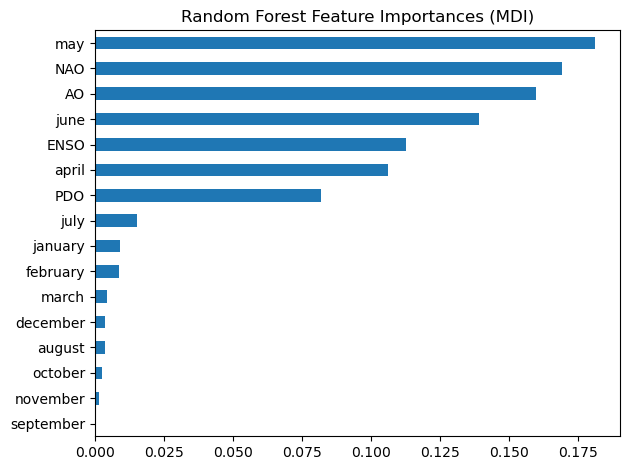

In [21]:
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()

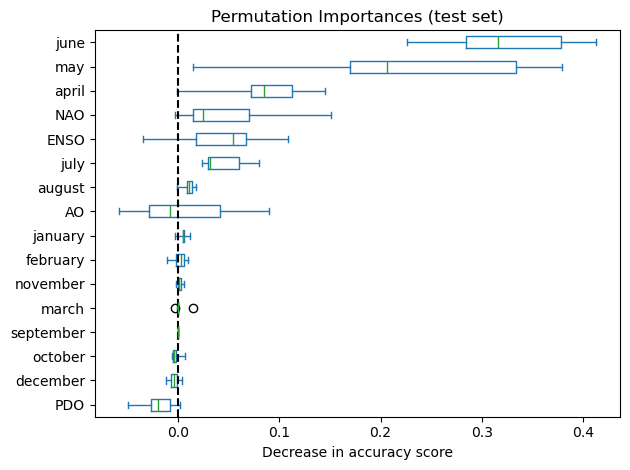

In [ ]:
# Constructing the multi-pass permutation importance

from sklearn.inspection import permutation_importance

result = permutation_importance(
    gbr_model_OH, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

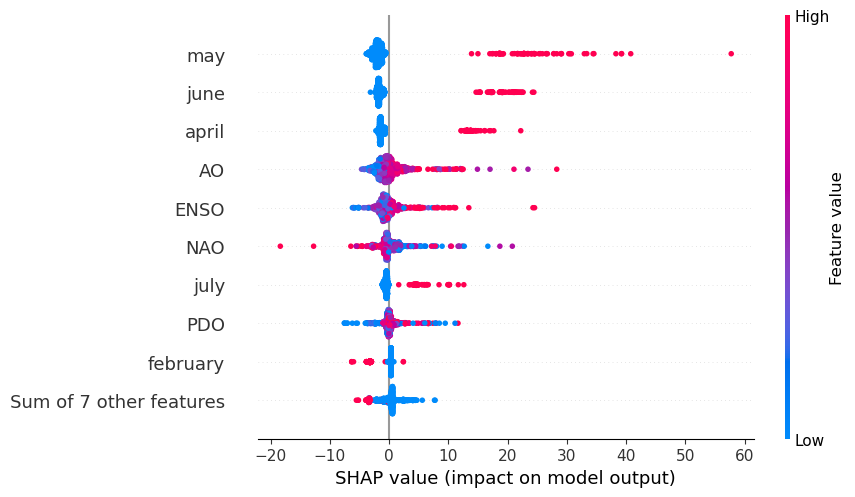

In [23]:
explainer = shap.Explainer(gbr_model_OH)
shap_values = explainer(X)

shap.plots.beeswarm(shap_values)

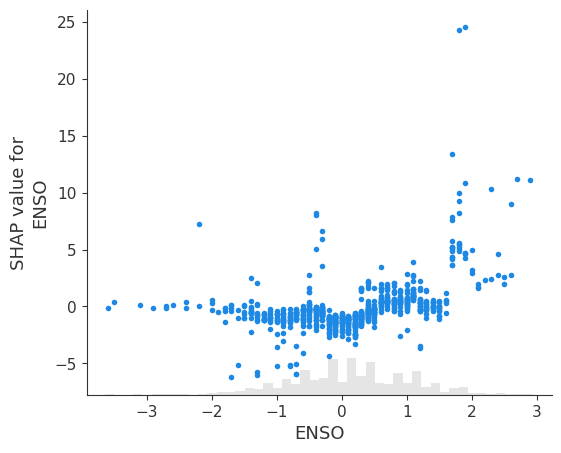

In [ ]:
# Feature Dependence plot for ENSO

Explanation = explainer(X)
shap.plots.scatter(Explanation[:, 'ENSO'])
